<a href="https://colab.research.google.com/github/yelsebety/Yassin-Flyrank/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yelsebety/Yassin-Flyrank/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding.* Web and traffic numbers are almost always **heavy-tailed**: a few giant pages and a long tail of tiny ones. That changes how I test signals, so I look at the shape of every field first.

**Slice:** starter-CSV pages with at least 1 impression and at least 90 days of age. **Reading rules:** a position of 0 means "no data", and `ctr` is a percentage (0.5 means 0.5%).

**What I check:** missing and zero shares, how far the mean sits above the median (a quick heavy-tail sign), and how correlation behaves on raw vs. log-transformed values.

In [1]:
import os, sys, subprocess, json, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

# Find the repo root so the CSV loads in Colab and locally.
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/yelsebety/Yassin-Flyrank.git"
REPO_DIR = "Yassin-Flyrank"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)

raw = pd.read_csv("data/raw/content_refresh_anonymized.csv")
raw["declined"] = (raw["trend_direction"] == "down").astype(int)   # outcome / evaluation only, never a feature

elig = raw[(raw["impressions_90d"] > 0) & (raw["content_age_days"] >= 90)].copy()
print(f"Eligible pages: {len(elig):,} from {elig['client_id'].nunique()} clients. Share marked 'down' (outcome only): {elig['declined'].mean():.3f}")
print(f"avg_position == 0 ('no data'): {(elig['avg_position'] == 0).sum():,} pages ({(elig['avg_position'] == 0).mean():.1%})\n")

FIELDS = [c for c in ["impressions_90d", "clicks_90d", "ctr", "avg_position", "word_count", "search_volume",
                      "days_since_last_update", "content_age_days", "days_with_impressions"] if c in elig.columns]
rows = []
for c in FIELDS:
    s = elig[c]; nz = s.dropna(); med = nz.median()
    rows.append({"field": c, "missing": s.isna().mean(), "zeros": (nz == 0).mean(),
                 "median": med, "p90": nz.quantile(0.90), "p99": nz.quantile(0.99), "max": nz.max(),
                 "mean / median": (nz.mean() / med) if med else np.nan, "skew": nz.skew()})
dist = pd.DataFrame(rows).round(3)
print("Distribution summary (a 'mean / median' far above 1 and a large skew mean a heavy tail):")
display(dist)

Eligible pages: 30,000 from 32 clients. Share marked 'down' (outcome only): 0.542
avg_position == 0 ('no data'): 1,205 pages (4.0%)

Distribution summary (a 'mean / median' far above 1 and a large skew mean a heavy tail):


,field,missing,zeros,median,p90,p99,max,mean / median,skew
0,impressions_90d,0.000,0.000,731.00,12136.40,73505.830,517715.0,7.114,11.385
1,clicks_90d,0.000,0.440,1.00,32.00,253.010,4178.0,16.097,18.346
2,ctr,0.000,0.440,0.07,0.65,8.330,100.0,7.296,17.444
3,avg_position,0.000,0.040,10.80,36.80,69.901,245.0,1.513,1.984
4,word_count,0.257,0.000,2877.00,5327.00,7292.000,9546.0,1.080,0.938
5,search_volume,0.082,0.402,10.00,110.00,2900.000,74000.0,15.888,26.016
6,days_since_last_update,0.000,0.000,20.00,104.00,106.000,373.0,2.305,1.161
7,content_age_days,0.000,0.000,236.00,463.00,537.000,564.0,1.085,0.489
8,days_with_impressions,0.000,0.000,81.00,88.00,88.000,88.0,0.759,-0.822


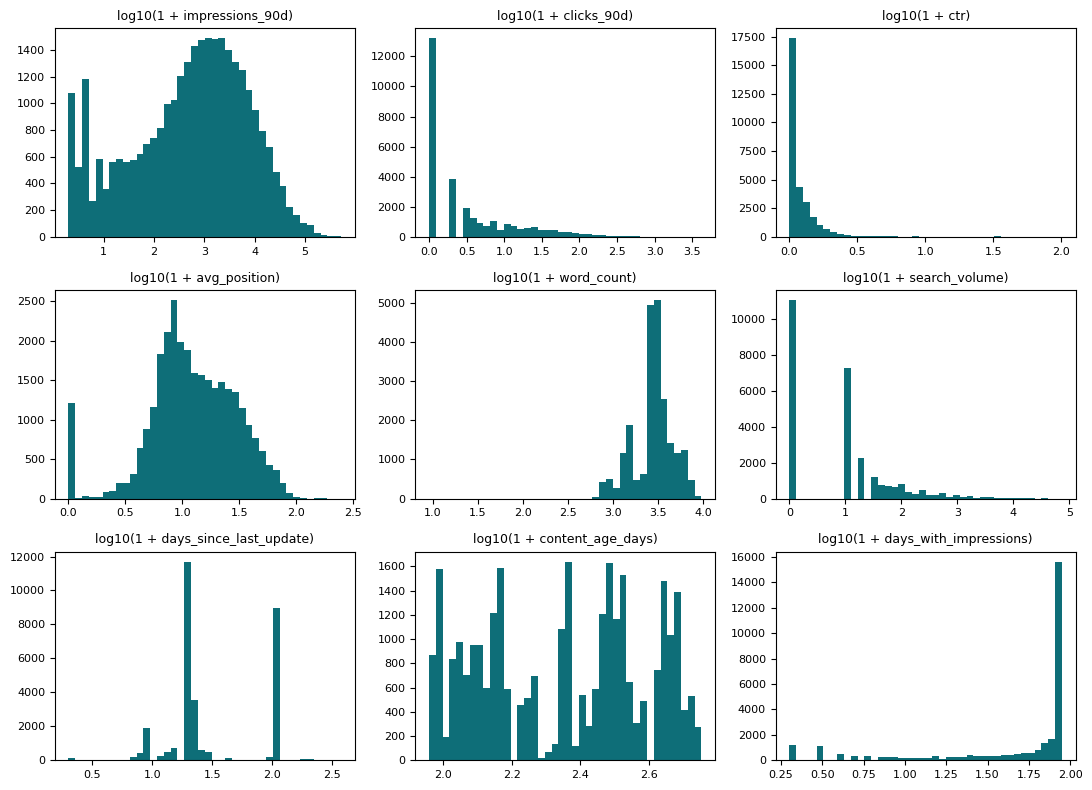

impressions_90d vs word_count (n = 22,301 pages with a word count)
  Pearson on raw values:   +0.163   (dominated by the giants)
  Pearson on log1p values: +0.383
  Spearman (rank-based):   +0.299
If these disagree, the raw-value number is not safe to quote. I use medians by bucket or log/rank methods below.


In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(11, 8))
for ax, c in zip(axes.ravel(), FIELDS):
    v = elig[c].dropna(); v = v[v >= 0]
    ax.hist(np.log10(1 + v), bins=40, color="#0e6e78")
    ax.set_title(f"log10(1 + {c})", fontsize=9); ax.tick_params(labelsize=8)
for ax in axes.ravel()[len(FIELDS):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

pair = elig[["impressions_90d", "word_count"]].dropna()
pair = pair[pair["word_count"] > 0]
print(f"impressions_90d vs word_count (n = {len(pair):,} pages with a word count)")
print(f"  Pearson on raw values:   {pair['impressions_90d'].corr(pair['word_count']):+.3f}   (dominated by the giants)")
print(f"  Pearson on log1p values: {np.log1p(pair['impressions_90d']).corr(np.log1p(pair['word_count'])):+.3f}")
print(f"  Spearman (rank-based):   {pair['impressions_90d'].corr(pair['word_count'], method='spearman'):+.3f}")
print("If these disagree, the raw-value number is not safe to quote. I use medians by bucket or log/rank methods below.")

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict.* "Safe" means ordinary page measurements, not product flags and not built from the outcome.

Every test has the same shape: the claim in one sentence, a bucket table with the number of pages (**n**) beside every value, and a verdict.

| Verdict | Rule I fixed before looking |
|---|---|
| **CONFIRMED** | at least 80% of the steps between buckets move the claimed way, and the first-to-last change is at least 10% of the typical value |
| **OPPOSITE** | the same, in the reverse direction |
| **FALSE** | buckets nearly flat (total spread under 20% of the typical value) |
| **MIXED** | something is going on, but not a clean one-direction pattern |
| **INSUFFICIENT DATA** | fewer than 3 buckets with at least 50 pages |

**The three claims:**
1. *Longer pages get more impressions* (median impressions by word-count fifth; medians, because impressions are heavy-tailed).
2. *Higher-ranked pages earn a higher click-through rate* (total clicks / total impressions by position band, not the average of page-level rates).
3. *Pages targeting higher search-volume keywords get more impressions* (median impressions by search-volume fifth).

**Does the verdict survive?** I repeat each test on two halves of the clients. A real pattern should show up in both.

In [3]:
PRACTICE = {
    "CONFIRMED": "Usable as an ordering hint in this data (still an association, not a cause).",
    "OPPOSITE": "The data shows the reverse of the claim. Do not build a rule on the claim.",
    "MIXED": "No clean one-direction pattern. Do not weight it in a rule without more evidence.",
    "FALSE": "No visible pattern. Drop it.",
    "INSUFFICIENT DATA": "Too few pages per bucket to say. That is a finding too.",
}

def judge(values, ns, expected, floor=50, min_effect=0.10):
    keep = [(v, n) for v, n in zip(values, ns) if n >= floor and pd.notna(v)]
    if len(keep) < 3:
        return "INSUFFICIENT DATA", {"buckets_used": len(keep)}
    v = np.array([k[0] for k in keep], dtype=float)
    scale = np.mean(np.abs(v))
    if not scale > 0:
        return "INSUFFICIENT DATA", {"buckets_used": len(keep)}
    sign = 1 if expected == "up" else -1
    steps = np.sign(np.diff(v)) * sign
    share_expected, share_opposite = float((steps > 0).mean()), float((steps < 0).mean())
    effect = sign * (v[-1] - v[0]) / scale
    spread = (v.max() - v.min()) / scale
    if share_expected >= 0.8 and effect >= min_effect:
        out = "CONFIRMED"
    elif share_opposite >= 0.8 and effect <= -min_effect:
        out = "OPPOSITE"
    elif spread < 2 * min_effect:
        out = "FALSE"
    else:
        out = "MIXED"
    return out, {"steps_in_claimed_direction": round(share_expected, 2), "first_to_last_change": round(float(effect), 2),
                 "buckets_used": len(keep)}

def table_wordcount(d):
    d = d[d["word_count"] > 0]
    b = pd.qcut(d["word_count"], 5, duplicates="drop")
    return d.groupby(b, observed=True)["impressions_90d"].agg(n="count", value="median")

def table_ctr_by_position(d):
    d = d[(d["avg_position"] > 0) & (d["impressions_90d"] >= 100)]
    b = pd.cut(d["avg_position"], [0, 3, 6, 10, 15, 20, 30, 1000])
    g = d.groupby(b, observed=True)
    return pd.DataFrame({"n": g.size(), "value": 100 * g["clicks_90d"].sum() / g["impressions_90d"].sum()})

def table_searchvolume(d):
    d = d[d["search_volume"] > 0]
    b = pd.qcut(d["search_volume"], 5, duplicates="drop")
    return d.groupby(b, observed=True)["impressions_90d"].agg(n="count", value="median")

clients = sorted(elig["client_id"].unique())
half_a = elig[elig["client_id"].isin(clients[0::2])]
half_b = elig[elig["client_id"].isin(clients[1::2])]

def run_test(name, claim, builder, expected, data=elig):
    print("=" * 78)
    print(f"{name}\nClaim: {claim}")
    t = builder(data)
    display(t.round(3))
    verdict, detail = judge(t["value"].tolist(), t["n"].tolist(), expected)
    print(f"VERDICT: {verdict}   {detail}")
    print("In practice:", PRACTICE[verdict])
    ta, tb = builder(half_a), builder(half_b)
    va, _ = judge(ta["value"].tolist(), ta["n"].tolist(), expected)
    vb, _ = judge(tb["value"].tolist(), tb["n"].tolist(), expected)
    print(f"Repeat on two client halves: half A = {va}, half B = {vb}  ->  {'survives' if va == vb == verdict else 'does NOT clearly survive'}")
    return {"test": name, "claim": claim, "verdict": verdict, "half_A": va, "half_B": vb}

results = []
results.append(run_test("Signal #1", "Longer pages get more impressions (median impressions by word-count fifth)", table_wordcount, "up"))
results.append(run_test("Signal #2", "Higher-ranked pages earn a higher CTR (weighted CTR % by position band, pages with 100+ impressions)", table_ctr_by_position, "down"))
results.append(run_test("Signal #3", "Higher search-volume keywords get more impressions (median impressions by search-volume fifth)", table_searchvolume, "up"))

Signal #1
Claim: Longer pages get more impressions (median impressions by word-count fifth)


,n,value
word_count,,
"(7.999, 1725.0]",4462,34.0
"(1725.0, 2724.0]",4461,875.0
"(2724.0, 3060.0]",4465,1115.0
"(3060.0, 3973.0]",4453,631.0
"(3973.0, 9546.0]",4460,2133.0


VERDICT: MIXED   {'steps_in_claimed_direction': 0.75, 'first_to_last_change': 2.19, 'buckets_used': 5}
In practice: No clean one-direction pattern. Do not weight it in a rule without more evidence.
Repeat on two client halves: half A = CONFIRMED, half B = MIXED  ->  does NOT clearly survive
Signal #2
Claim: Higher-ranked pages earn a higher CTR (weighted CTR % by position band, pages with 100+ impressions)


,n,value
avg_position,,
"(0, 3]",555,0.489
"(3, 6]",3436,0.402
"(6, 10]",5224,0.278
"(10, 15]",3524,0.355
"(15, 20]",2352,0.339
"(20, 30]",3333,0.194
"(30, 1000]",3582,0.094


VERDICT: CONFIRMED   {'steps_in_claimed_direction': 0.83, 'first_to_last_change': 1.29, 'buckets_used': 7}
In practice: Usable as an ordering hint in this data (still an association, not a cause).
Repeat on two client halves: half A = CONFIRMED, half B = CONFIRMED  ->  survives
Signal #3
Claim: Higher search-volume keywords get more impressions (median impressions by search-volume fifth)


,n,value
search_volume,,
"(9.999, 30.0]",10825,875.0
"(30.0, 90.0]",2577,858.0
"(90.0, 74000.0]",3049,818.0


VERDICT: FALSE   {'steps_in_claimed_direction': 0.0, 'first_to_last_change': -0.07, 'buckets_used': 3}
In practice: No visible pattern. Drop it.
Repeat on two client halves: half A = MIXED, half B = FALSE  ->  does NOT clearly survive


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

Two flag assumptions can be tested with the outcome label (`trend_direction`), used here **only as the thing being tested, never as an input**:

- **Refresh flags assume staleness hurts.** *Test A:* the longer since the last update, the more often a page is marked "down" (impressions over the last 30 days more than 20% below the 30 days before).
- **Quick-win flags assume pages just off page one have the most room to grow.** *Test B:* the share marked "up" should rise from the top of page one toward positions 11 to 20.

Same rules: n beside every value, a floor of 50 pages, and a repeat on two client halves.

In [4]:
def table_staleness_down(d):
    b = pd.cut(d["days_since_last_update"], [0, 30, 90, 180, 10**6], right=False,
               labels=["0-29 d", "30-89 d", "90-179 d", "180+ d"])
    return d.groupby(b, observed=True)["declined"].agg(n="count", value="mean")

def table_striking_up(d):
    d = d[(d["avg_position"] > 0) & (d["impressions_90d"] >= 100)].copy()
    d["is_up"] = (d["trend_direction"] == "up").astype(int)
    b = pd.cut(d["avg_position"], [0, 3, 10, 20, 1000], labels=["1-3", "4-10", "11-20", "21+"])
    return d.groupby(b, observed=True)["is_up"].agg(n="count", value="mean")

flag_results = []
flag_results.append(run_test("Flag-linked test A (refresh flags / staleness)",
                             "The longer since the last update, the more often a page is marked 'down'", table_staleness_down, "up"))
flag_results.append(run_test("Flag-linked test B (quick-win flags / striking distance)",
                             "The share marked 'up' rises toward positions 11-20 (more room to grow)", table_striking_up, "up"))

Flag-linked test A (refresh flags / staleness)
Claim: The longer since the last update, the more often a page is marked 'down'


,n,value
days_since_last_update,,
0-29 d,20480,0.511
30-89 d,175,0.589
90-179 d,9171,0.611
180+ d,174,0.471


VERDICT: MIXED   {'steps_in_claimed_direction': 0.67, 'first_to_last_change': -0.07, 'buckets_used': 4}
In practice: No clean one-direction pattern. Do not weight it in a rule without more evidence.
Repeat on two client halves: half A = MIXED, half B = FALSE  ->  does NOT clearly survive
Flag-linked test B (quick-win flags / striking distance)
Claim: The share marked 'up' rises toward positions 11-20 (more room to grow)


,n,value
avg_position,,
1-3,555,0.056
4-10,8660,0.129
11-20,5876,0.126
21+,6915,0.216


VERDICT: MIXED   {'steps_in_claimed_direction': 0.67, 'first_to_last_change': 1.22, 'buckets_used': 4}
In practice: No clean one-direction pattern. Do not weight it in a rule without more evidence.
Repeat on two client halves: half A = CONFIRMED, half B = MIXED  ->  does NOT clearly survive


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

A **CONFIRMED** verdict that **survives on both client halves** is a reasonable ordering hint. **MIXED, FALSE, OPPOSITE or INSUFFICIENT DATA** means the belief behind that signal does not show up cleanly in this data, and a rule should not lean on it. A verdict that flips between halves is a reason for caution, not a finding. Everything here is an association in one snapshot; none of it shows that a change to a page would cause a result.

In [5]:
summary = pd.DataFrame(results + flag_results)
summary["survives on both halves"] = (summary["verdict"] == summary["half_A"]) & (summary["verdict"] == summary["half_B"])
display(summary[["test", "verdict", "half_A", "half_B", "survives on both halves"]])

solid = summary[(summary["verdict"] == "CONFIRMED") & summary["survives on both halves"]]
weak = summary[~summary.index.isin(solid.index)]
print("What a content team can take from this (generated from the table above):")
print(f"1. Of {len(summary)} tests, {len(solid)} were CONFIRMED and held on both client halves"
      + (f" ({'; '.join(solid['test'])})." if len(solid) else "."))
print(f"2. The other {len(weak)} were MIXED, FALSE, OPPOSITE, INSUFFICIENT DATA, or did not hold on both halves, "
      "so a rule should not lean on those beliefs in this data.")
print("3. These are observed associations in one snapshot: a basis for deciding which pages to review first, not evidence that an edit would cause a change.")

,test,verdict,half_A,half_B,survives on both halves
0,Signal #1,MIXED,CONFIRMED,MIXED,False
1,Signal #2,CONFIRMED,CONFIRMED,CONFIRMED,True
2,Signal #3,FALSE,MIXED,FALSE,False
3,Flag-linked test A (refresh flags / staleness),MIXED,MIXED,FALSE,False
4,Flag-linked test B (quick-win flags / striking distance),MIXED,CONFIRMED,MIXED,False


What a content team can take from this (generated from the table above):
1. Of 5 tests, 1 were CONFIRMED and held on both client halves (Signal #2).
2. The other 4 were MIXED, FALSE, OPPOSITE, INSUFFICIENT DATA, or did not hold on both halves, so a rule should not lean on those beliefs in this data.
3. These are observed associations in one snapshot: a basis for deciding which pages to review first, not evidence that an edit would cause a change.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.